In [11]:
import fastf1 as ff1
from fastf1 import plotting

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from utility import set_dark

# local cache to avoid repeated downloads
ff1.Cache.enable_cache('./data/cache')

# Focusing on Max Verstappen

### Analyzing Max Verstappen's Qualifying pace
Max Verstappen Eliminated in Q1 on Pure Pace (not due to accidents) For the First Time in his Career!

Let's analyze his qualifying pace in Q1 and the car setup compared to others. 

In [12]:
session_q = ff1.get_session(2025, 'Brazil', 'Q')

session_q.load()

core           INFO 	Loading data for São Paulo Grand Prix - Qualifying [v3.6.1]
req            INFO 	Using cached data for session_info


req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
core        WARNING 	No lap data for driver 5
core        WARNING 	Failed to perform lap accuracy check - all laps marked as inaccurate (driver 5)
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['4', '12', '16', '81', '6', '63', '30', '87', '10', '27', '14', '23', '44', '18', '55', '1', '31', '43', '22', '5']


In [13]:
drivers = [
    "NOR",
    "VER",
    "PIA",
    "RUS",
    "LEC",
    "HAM",
    "ANT",
    "ALB",
    "HUL",
    "SAI",
    "ALO",
    "STR",
    "OCO",
    "TSU",
    "GAS",
    "HAD",
    "BOR",
    "LAW",
    "BEA",
    "COL"
]
laps = session_q.laps.pick_not_deleted()
q1, q2, q3 = laps.split_qualifying_sessions()


# Only care Q1
# sector 1

# https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html#copy-on-write 
pd.options.mode.copy_on_write = True 

def sector_time(q, sector:str ='Sector1Time') -> pd.DataFrame:
    sector_data = {
        'Driver': [],
        sector: [], 
        'Color': []
    }
    for driver in drivers:
        driver_laps = q.pick_drivers(driver)
            
        # laps.pick_fastest() => pd.Series
        best_lap = driver_laps.pick_fastest()
        if best_lap is None: continue
        
        best_lap[sector] = pd.to_timedelta(best_lap[sector])
        s1 = best_lap[sector].total_seconds()
        # s2 = best_lap['Sector2Time'].dt.total_seconds()
        # s3 = best_lap['Sector3Time'].dt.total_seconds()
        
        sector_data['Driver'].append(driver)
        sector_data[sector].append(s1)
        
        color = plotting.get_driver_color(driver, session_q)
        sector_data['Color'].append(color)

    sector_total = pd.DataFrame(sector_data)
    return sector_total

sector1 = sector_time(q1, 'Sector1Time')
sector2 = sector_time(q1, 'Sector2Time')
sector3 = sector_time(q1, 'Sector3Time')

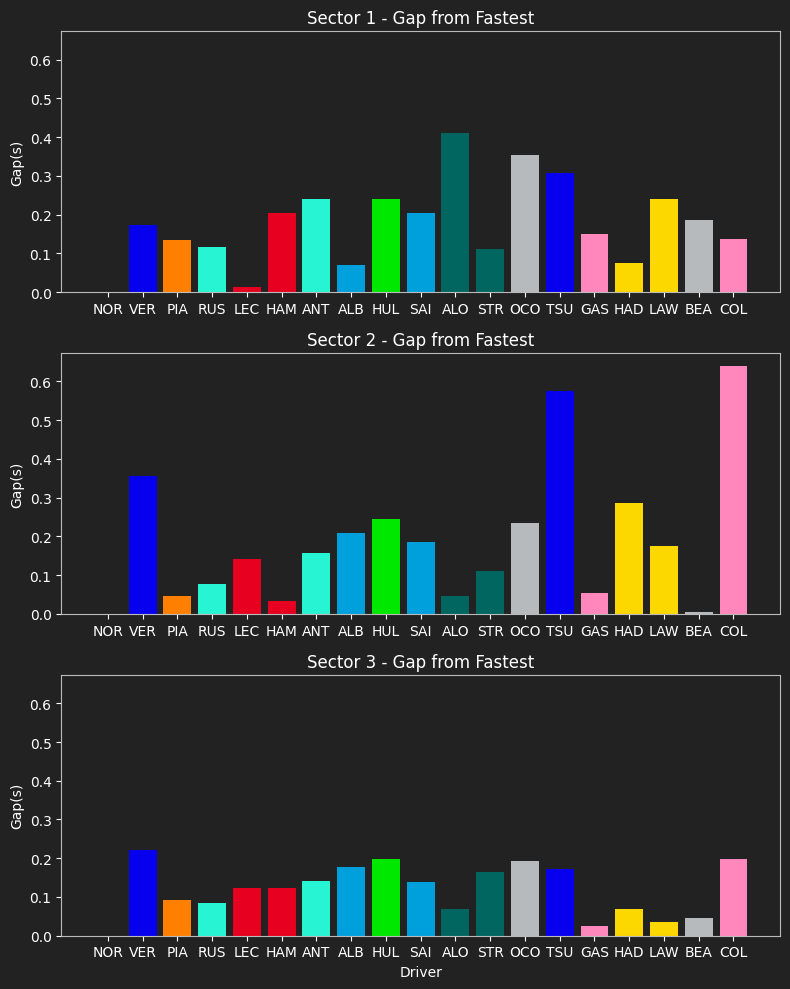

In [14]:
# consistent scale was needed for the three graphs
# get the maximum gap in sector1, sector2, sector3
sector1_gap = sector1.copy()
sector1_gap['Gap'] = sector1_gap['Sector1Time'] - sector1_gap['Sector1Time'].min()

sector2_gap = sector2.copy()
sector2_gap['Gap'] = sector2_gap['Sector2Time'] - sector2_gap['Sector2Time'].min()

sector3_gap = sector3.copy()
sector3_gap['Gap'] = sector3_gap['Sector3Time'] - sector3_gap['Sector3Time'].min()

max_gap = max(sector1_gap['Gap'].max(), sector2_gap['Gap'].max(), sector3_gap['Gap'].max())
# add margin
y_max = max_gap * 1.05

# viz time
fig, ax = plt.subplots(3, 1, figsize=(8, 10))
set_dark(ax[0])
set_dark(ax[1])
set_dark(ax[2])

# or use sns.barplot(data=sector1_gap, x=, y=, ax=ax[0], ...)
ax[0].bar(sector1_gap['Driver'], sector1_gap['Gap'], color=sector1_gap['Color'])
ax[0].set_ylim(0, y_max)
ax[0].set_title('Sector 1 - Gap from Fastest')
ax[0].set_ylabel('Gap(s)')

ax[1].bar(sector2_gap['Driver'], sector2_gap['Gap'], color=sector1_gap['Color'])
ax[1].set_ylim(0, y_max)
ax[1].set_title('Sector 2 - Gap from Fastest')
ax[1].set_ylabel('Gap(s)')

ax[2].bar(sector3_gap['Driver'], sector3_gap['Gap'], color=sector1_gap['Color'])
ax[2].set_ylim(0, y_max)
ax[2].set_title('Sector 3 - Gap from Fastest')
ax[2].set_ylabel('Gap(s)')
ax[2].set_xlabel('Driver')

plt.tight_layout()
plt.show()

- __NOR__ was the fastest in all 3 sectors!
- Both Red Bulls:__VER__ and __TSU__ remarkably struggled compared to the others.   
It shows how slow Red Bull cars were compared to the other teams.
- __VER__ was behind __NOR__ more than 0.2 seconds per sector. 

### Verstappen's Pace on Race Session

#### Comparing Drivers' Lap Times

In [15]:
session_r = ff1.get_session(2025, 'Brazil', 'R')
session_r.load()

core           INFO 	Loading data for São Paulo Grand Prix - Race [v3.6.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core        WARNING 	Driver 4 completed the race distance 00:00.010000 before the recorded end of the session.
core           INFO 	Finished loading data for 20 drivers: ['4', '12', '1', '63', '81', '87', '30', '6', '27', '10', '23', '3

In [16]:
driver_laps = session_r.laps.pick_drivers(drivers).pick_quicklaps()

# driver numbers in finishing order (NOR: 4, VER: 1, ...)
# remove DNF drivers.: HAM, LEC, BOR
order_num = session_r.drivers[:-3]
order_data = {
    'Driver': [],
    'Color': []
}
for number in order_num:
    driver_abbr = session_r.get_driver(number)['Abbreviation']
    order_data['Driver'].append(driver_abbr)
    order_data['Color'].append(ff1.plotting.get_driver_color(driver_abbr, session_r))
order_data

req            INFO 	Using cached data for driver_info


{'Driver': ['NOR',
  'ANT',
  'VER',
  'RUS',
  'PIA',
  'BEA',
  'LAW',
  'HAD',
  'HUL',
  'GAS',
  'ALB',
  'OCO',
  'SAI',
  'ALO',
  'COL',
  'STR',
  'TSU'],
 'Color': ['#ff8000',
  '#27f4d2',
  '#0600ef',
  '#27f4d2',
  '#ff8000',
  '#b6babd',
  '#fcd700',
  '#fcd700',
  '#00e700',
  '#ff87bc',
  '#00a0dd',
  '#b6babd',
  '#00a0dd',
  '#00665f',
  '#ff87bc',
  '#00665f',
  '#0600ef']}

/var/folders/qc/jmq73tl56x15yys44c4wj6qr0000gn/T/ipykernel_19590/2089385879.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=driver_laps, x='Driver', y='LapTimeSec', palette=order_data['Color'], order=order_data['Driver'])


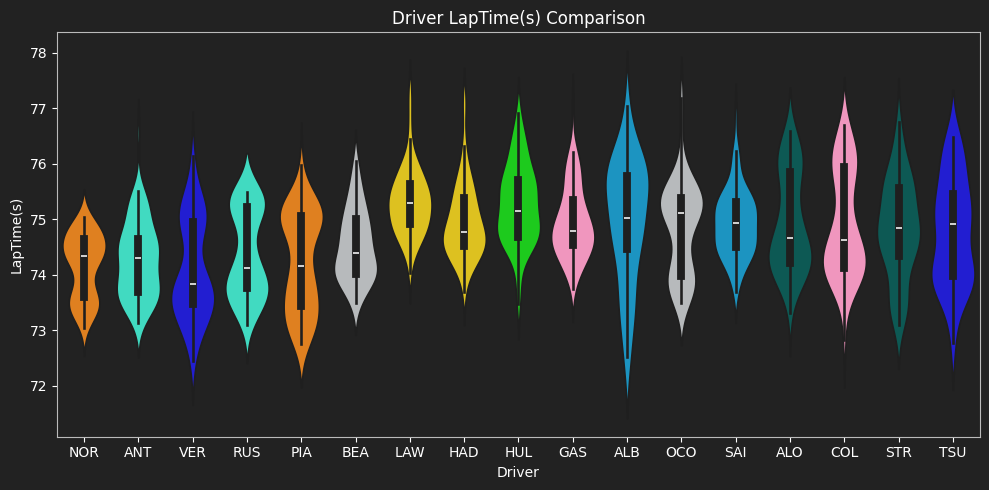

In [17]:
fig, ax = plt.subplots(figsize=(10, 5))
set_dark(ax)

driver_laps['LapTimeSec'] = driver_laps['LapTime'].dt.total_seconds()

sns.violinplot(data=driver_laps, x='Driver', y='LapTimeSec', palette=order_data['Color'], order=order_data['Driver'])

ax.set_title('Driver LapTime(s) Comparison')
ax.set_ylabel('LapTime(s)')

plt.tight_layout()
plt.show()

- __NOR__ was very consistent during the race
- __VER__ has a fast median laptime and wide kde density at around 73~75. His performance stepped up compared to the qualifying session.   
This might be due to his __power-unit change__ after the qualifying session. 

#### Change in Verstappen Car's Pace (mean speed, max speed, compared to others, both in Q, R)

In [41]:
# get_car_data() instead of get_telemetry() to retreive only car data
ver_fastest_q1_lap = q1.pick_drivers('VER').pick_fastest()
telemetry = q1.pick_drivers('VER').pick_fastest().get_car_data()
# telemetry.head(10)
np.mean(telemetry['Speed']), np.max(telemetry['Speed'])

(np.float64(220.18450184501845), np.float64(338.0))

In [42]:
# temp = q1.pick_drivers('VER').pick_fastest()
# temp2 = q1.pick_drivers('NOR').pick_fastest()
# temp['LapTime'] < temp2['LapTime']

In [58]:
## Helper Functions!

def get_best_quali_lap(driver):
    laps = []
    for q in [q1, q2, q3]:
        lap = q.pick_drivers(driver).pick_fastest()
        if lap is not None:
            laps.append(lap)

    best_lap = min(laps, key=lambda x: x['LapTime'])
    return best_lap


def avg_max_speed(driver, session='Q'):
    best_lap = None
    if session == 'Q':
        best_lap = get_best_quali_lap(driver)
    else:
        best_lap = session_r.laps.pick_drivers(driver).pick_fastest()
    # car_data = session.pick_drivers(driver).pick_fastest().get_car_data()
    car_data = best_lap.get_car_data()
    mean_speed = np.mean(car_data['Speed'])
    max_speed = np.max(car_data['Speed'])

    return [mean_speed, max_speed]

In [59]:
speed_data_q = {
    'Drivers': [],
    'Average Speed': [],
    'Max Speed': [],
    'Color': []
}
# order doesn't really matter for this plot, but used it for convenience.
for driver, color in zip(order_data['Driver'], order_data['Color']):
    mean_speed, max_speed = avg_max_speed(driver, 'Q')
    speed_data_q['Drivers'].append(driver)
    speed_data_q['Average Speed'].append(mean_speed)
    speed_data_q['Max Speed'].append(max_speed)
    speed_data_q['Color'].append(color)

speed_data = pd.DataFrame(speed_data_q)


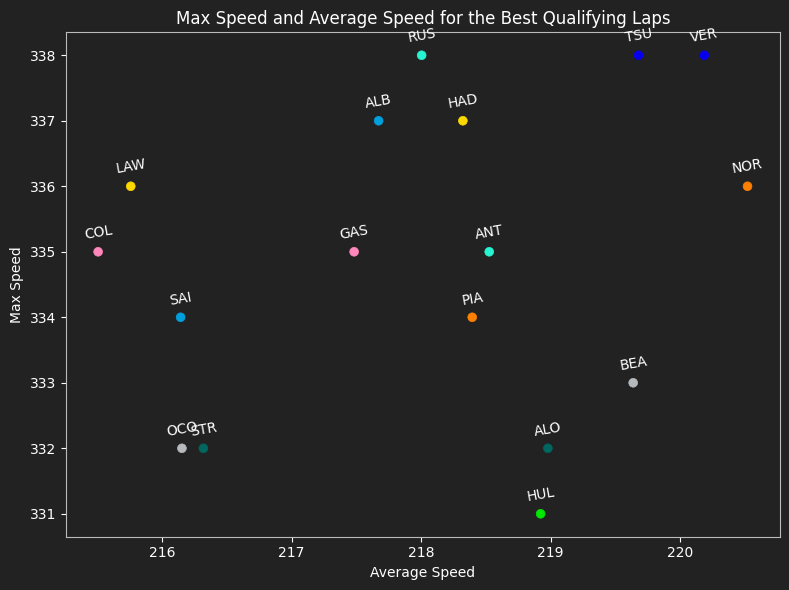

In [60]:
fig, ax = plt.subplots(figsize=(8, 6))
set_dark(ax)

sns.scatterplot(data=speed_data_q, x='Average Speed', y='Max Speed', palette=order_data['Color'], hue='Drivers', s=40, edgecolor=None)

for _, row in speed_data.iterrows():
    ax.text(x=row['Average Speed'], y=row['Max Speed'] + 0.15, s=row['Drivers'], ha='center', va='bottom', color='white', rotation=10)

ax.get_legend().remove()

ax.set_title('Max Speed and Average Speed for the Best Qualifying Laps')
ax.set_xlabel('Average Speed')
ax.set_ylabel('Max Speed')
plt.tight_layout()
plt.show()

- The higher the average speed and the top speed, the less draf the car has.
- Surprisingly, both Red Bulls had high speeds. This means the car had __less drag__ compared to others. 
- __Interlagos__, the circuit for Brazil GP, requries a drag-setup. 
- This explains why both Red Bulls struggled in the qualifying. 

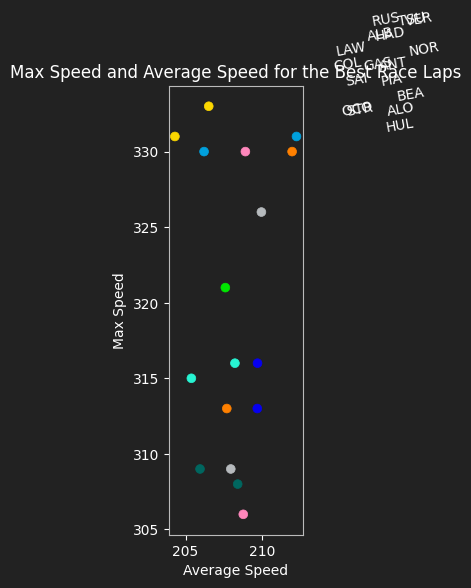

In [ ]:
speed_data_r = {
    'Drivers': [],
    'Average Speed': [],
    'Max Speed': [],
    'Color': []
}
# order doesn't really matter for this plot, but used it for convenience.
for driver, color in zip(order_data['Driver'], order_data['Color']):
    mean_speed, max_speed = avg_max_speed(driver, 'R')
    speed_data_r['Drivers'].append(driver)
    speed_data_r['Average Speed'].append(mean_speed)
    speed_data_r['Max Speed'].append(max_speed)
    speed_data_r['Color'].append(color)

speed_data_r = pd.DataFrame(speed_data_r)

fig, ax = plt.subplots(figsize=(8, 6))
set_dark(ax)

sns.scatterplot(data=speed_data_r, x='Average Speed', y='Max Speed', palette=order_data['Color'], hue='Drivers', s=40, edgecolor=None)

for _, row in speed_data.iterrows():
    ax.text(x=row['Average Speed'], y=row['Max Speed'] + 0.15, s=row['Drivers'], ha='center', va='bottom', color='white', rotation=10)

ax.get_legend().remove()

ax.set_title('Max Speed and Average Speed for the Best Race Laps')
ax.set_xlabel('Average Speed')
ax.set_ylabel('Max Speed')
plt.tight_layout()
plt.show()


## TODO: NEEDS FIX WTH
